In [1]:
# 1. Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import warnings

from keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
warnings.filterwarnings('ignore')

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


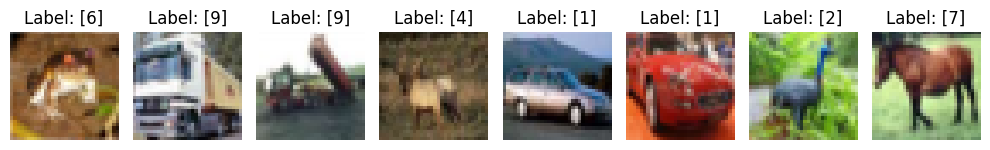

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

plt.figure(figsize=(10, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
# 2. Загрузка и предобработка CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Нормализация пикселей [0,1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Метки: из (50000,1) в (50000,) для удобства
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

num_classes = 10

# 3. Разделение train на train + val (80/10/10 от общего количества)
# Исходный CIFAR-10 имеет 50000 тренировочных и 10000 тестовых.
# Создадим train (40000), val (10000), test (10000) — test уже есть.
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full,
                                                  test_size=0.2, random_state=42,
                                                  stratify=y_train_full)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# Преобразование меток в one-hot
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

Train: (40000, 32, 32, 3), Val: (10000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [4]:
# 4. Построение модели CNN (та же архитектура, что и для букв)
model = keras.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Блок 2: два свёрточных слоя 3×3, затем пулинг и дропаут
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Классификатор
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 5. Обучение
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                            restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.4139 - loss: 1.6020 - val_accuracy: 0.5614 - val_loss: 1.2010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5746 - loss: 1.1909 - val_accuracy: 0.6453 - val_loss: 1.0090
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.6403 - loss: 1.0217 - val_accuracy: 0.6704 - val_loss: 0.9338
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.6786 - loss: 0.9194 - val_accuracy: 0.7035 - val_loss: 0.8515
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.6986 - loss: 0.8566 - val_accuracy: 0.7255 - val_loss: 0.7767
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7175 - loss: 0.7993 - val_accuracy: 0.7227 - val_loss: 0.8022
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7336 - loss: 0.7576 - val_accuracy: 0.7271 - val_loss: 0.7947
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - accuracy: 0.7463 -

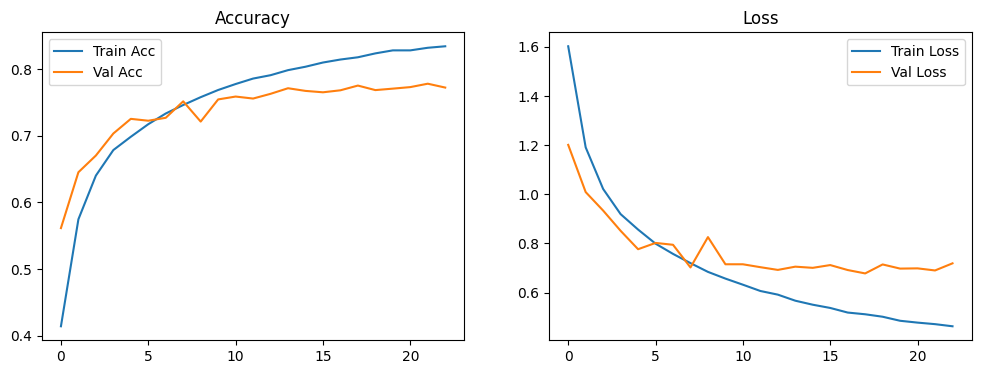

Точность на тестовых данных CIFAR-10: 0.7641


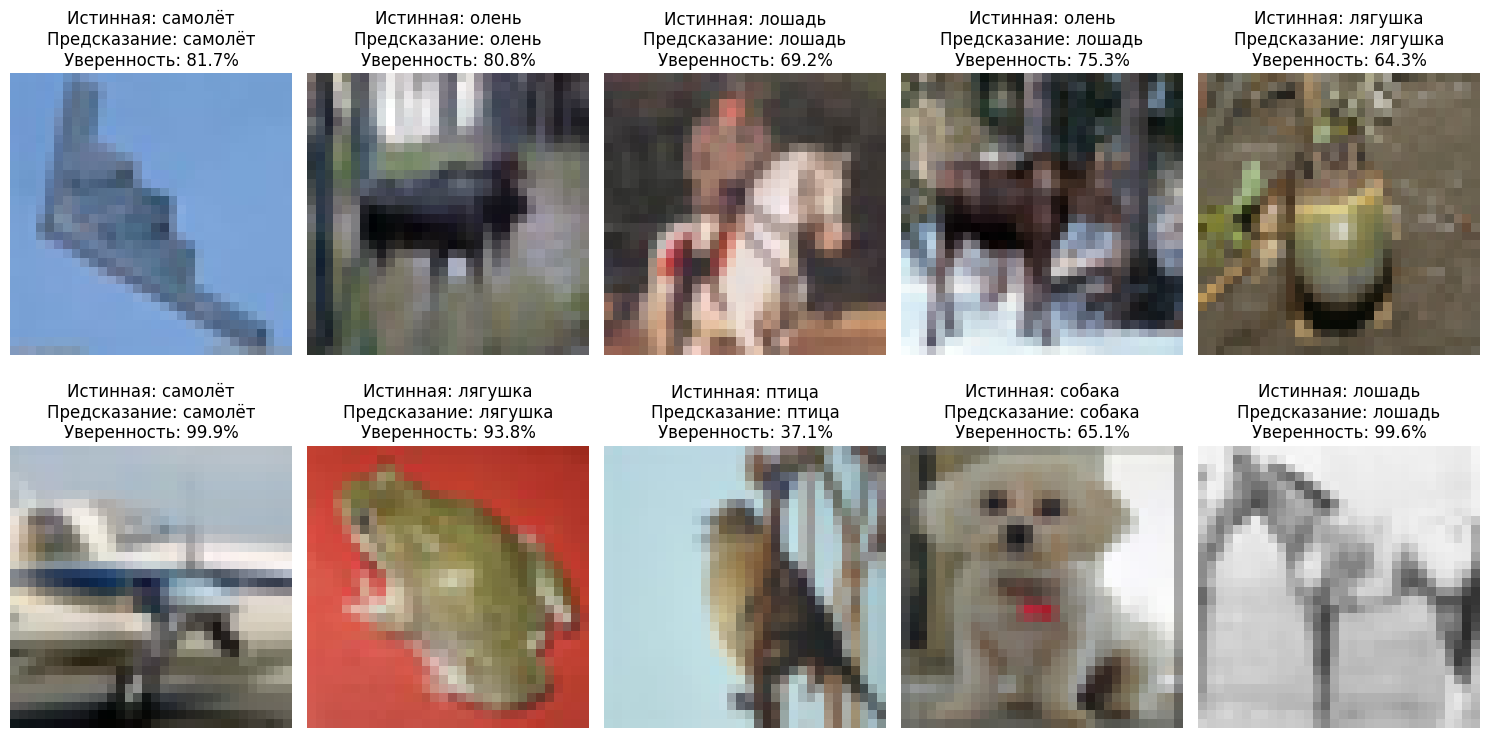

In [6]:

# 6. Визуализация обучения
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# 7. Оценка на тестовой выборке
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Точность на тестовых данных CIFAR-10: {test_acc:.4f}")

# 8. Функция предсказания для одного изображения (возвращает имя класса и уверенность)
class_names = ['самолёт', 'автомобиль', 'птица', 'кошка', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

def predict_image(image, model, class_names):
    if image.ndim == 3:
        image = np.expand_dims(image, axis=0)
    probs = model.predict(image, verbose=0)[0]
    max_prob = np.max(probs)
    pred_class = np.argmax(probs)
    return class_names[pred_class], max_prob * 100

# 9. Вывод 10 случайных изображений из тестовой выборки с предсказаниями
n_samples = 10
indices = np.random.choice(len(x_test), n_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    sample_img = x_test[idx]
    true_label = class_names[y_test[idx]]
    pred_label, conf = predict_image(sample_img, model, class_names)

    plt.subplot(2, 5, i+1)
    plt.imshow(sample_img)
    plt.title(f"Истинная: {true_label}\nПредсказание: {pred_label}\nУверенность: {conf:.1f}%")
    plt.axis('off')

plt.tight_layout()
plt.show()